# Notebook 2 — CNN From Scratch
## Optimizer & LR Comparison | Frontal + Lateral | 70 Epochs

| Setting | Value |
|---|---|
| CNN | Built from scratch (no pretrained weights) |
| Input | Frontal + Lateral images (fused) |
| Optimizers | SGD, Adam, AdamW, RMSProp |
| LR per optimizer | 0.01, 0.001, 0.0001 (best LR auto-selected) |
| Epochs | 70 each |
| Image Size | 128×128 |
| Batch Size | 16 (safe for 6GB GPU + dual images) |
| Save Folder | `ScratchCnnModels/` |

**Structure:**
```
Cell 1  → Imports & Config
Cell 2  → Create Folder
Cell 3  → Load Data
Cell 4  → Dataset (Frontal + Lateral) & DataLoaders
Cell 5  → CNN Architecture
Cell 6  → Train/Eval Functions
Cell 7  → TRAIN SGD     (70 epochs) → Save
Cell 8  → TRAIN Adam    (70 epochs) → Save
Cell 9  → TRAIN AdamW   (70 epochs) → Save
Cell 10 → TRAIN RMSProp (70 epochs) → Save
Cell 11 → Final Comparison Table
Cell 12 → Comparison Graphs
Cell 13 → Best Model Test Evaluation
Cell 14 → Per-Class Accuracy
Cell 15 → Load Saved Models (VS Code)
```

## Cell 1 — Imports & Config

In [1]:
import os, warnings, time, json, shutil
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Config optimised for 16GB RAM + 6GB GPU ───────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0        # Windows safe
IMG_SIZE    = 128      # 128×128 → 4× faster than 224×224
BATCH_SIZE  = 16       # 16 safe for 6GB GPU with DUAL images
EPOCHS      = 70       # full 70 epochs per optimizer
PIN_MEMORY  = torch.cuda.is_available()
SAVE_DIR    = Path('ScratchCnnModels')

# Best LR per optimizer (single, research-optimal)
BEST_LRS = {
    'SGD'    : 0.01,
    'Adam'   : 0.001,
    'AdamW'  : 0.001,
    'RMSProp': 0.001,
}

# 14 disease labels
FINDINGS_COLS = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia',
    'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices', 'No Finding',
]
NUM_CLASSES = len(FINDINGS_COLS)

# Store all results across optimizers
ALL_RESULTS  = []   # final best of each optimizer
ALL_HISTORIES= {}   # epoch history of each optimizer

print(f' Device     : {DEVICE}')
print(f' Image Size : {IMG_SIZE}×{IMG_SIZE}')
print(f' Batch Size : {BATCH_SIZE} (dual images)')
print(f' Epochs     : {EPOCHS} per optimizer')
print(f' Best LRs   : {BEST_LRS}')
print(f' Classes    : {NUM_CLASSES}')

d:\Projects\ScratchRadiology\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Device     : cuda
 Image Size : 128×128
 Batch Size : 16 (dual images)
 Epochs     : 70 per optimizer
 Best LRs   : {'SGD': 0.01, 'Adam': 0.001, 'AdamW': 0.001, 'RMSProp': 0.001}
 Classes    : 14


## Cell 2 — Create ScratchCnnModels Folder

In [2]:
SAVE_DIR.mkdir(exist_ok=True)
print(f' Folder ready : {SAVE_DIR.resolve()}')
print('  All models will be saved here.')

 Folder ready : D:\Projects\ScratchRadiology\ScratchCnnModels
  All models will be saved here.


## Cell 3 — Load Data from Notebook 1

In [3]:
df = pd.read_csv('preprocessed_df.csv')
df['findings_clean']   = df['findings_clean'].fillna('')
df['impression_clean'] = df['impression_clean'].fillna('')
df['clinical_history'] = df.get('clinical_history',
                          pd.Series(['']*len(df))).fillna('')

print(f' Loaded : {len(df)} rows | {len(df.columns)} columns')

# ── Extract labels if missing ─────────────────────────────────
missing = [c for c in FINDINGS_COLS if c not in df.columns]
if missing:
    print(f'Extracting {len(missing)} label columns...')
    PATHOLOGY_KEYWORDS = {
        'Enlarged Cardiomediastinum': ['cardiomediastinal enlargement','mediastinal widening'],
        'Cardiomegaly'              : ['cardiomegaly','enlarged heart','cardiac enlargement','heart size enlarged'],
        'Lung Opacity'              : ['opacity','opacities','airspace opacity','lung opacity'],
        'Lung Lesion'               : ['lesion','nodule','mass','pulmonary nodule'],
        'Edema'                     : ['edema','pulmonary edema','fluid overload'],
        'Consolidation'             : ['consolidation','airspace disease','infiltrate'],
        'Pneumonia'                 : ['pneumonia','infection','pneumonic'],
        'Atelectasis'               : ['atelectasis','collapse'],
        'Pneumothorax'              : ['pneumothorax','collapsed lung'],
        'Pleural Effusion'          : ['pleural effusion','effusion','fluid in pleural space'],
        'Pleural Other'             : ['pleural thickening','pleural abnormality'],
        'Fracture'                  : ['fracture','broken rib','rib fracture'],
        'Support Devices'           : ['tube','catheter','pacemaker','device','line'],
        'No Finding'                : ['normal','no acute','unremarkable','clear lungs'],
    }
    NEGATIONS = ['no ','without ','absence of ','no evidence of ']

    def extract_labels(row):
        text = (row['clinical_history']+' '+
                row['findings_clean']+' '+
                row['impression_clean']).lower()
        result = {}
        for col, kws in PATHOLOGY_KEYWORDS.items():
            found = False
            for kw in kws:
                if kw in text:
                    if not any((neg+kw) in text for neg in NEGATIONS):
                        found = True; break
            result[col] = int(found)
        return result

    label_df = df.apply(extract_labels, axis=1, result_type='expand')
    df = pd.concat([df, label_df], axis=1)
    df.to_csv('preprocessed_df_with_labels.csv', index=False)
    print(' Labels extracted & saved')
else:
    print(' Labels already present')

print('\nPositive label counts:')
print(df[FINDINGS_COLS].sum().sort_values(ascending=False).to_string())

 Loaded : 3337 rows | 13 columns
Extracting 14 label columns...
 Labels extracted & saved

Positive label counts:
No Finding                    3166
Pleural Effusion              2545
Consolidation                 1816
Pneumothorax                  1406
Lung Opacity                   664
Atelectasis                    321
Support Devices                298
Lung Lesion                    295
Cardiomegaly                   253
Edema                          241
Pneumonia                      237
Fracture                       171
Pleural Other                   27
Enlarged Cardiomediastinum       2


## Cell 4 — Dataset (Frontal + Lateral) & DataLoaders
> Both frontal and lateral images are loaded, resized, and **concatenated channel-wise** → 6-channel input to CNN

In [4]:
# ── Train / Val / Test split ──────────────────────────────────
train_df, temp_df = train_test_split(df,      test_size=0.2,  random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5,  random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# ── Transforms ────────────────────────────────────────────────
def get_transforms(is_training=True):
    norm = A.Normalize(mean=[0.485,0.456,0.406],
                       std =[0.229,0.224,0.225])
    if is_training:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05,
                               scale_limit=0.05,
                               rotate_limit=5, p=0.3),
            norm, ToTensorV2(),
        ])
    return A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), norm, ToTensorV2()])

# ── Dataset: loads frontal + lateral, concatenates channels ───
class DualChestDataset(Dataset):
    """
    Returns a 6-channel tensor:
      channels 0-2 → frontal image (RGB)
      channels 3-5 → lateral image (RGB)
    If lateral path is missing, uses a black image.
    """
    def __init__(self, df, is_training=True):
        self.df        = df.reset_index(drop=True)
        self.transform = get_transforms(is_training)

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        """Load image, return black image if path missing."""
        try:
            img = cv2.imread(str(path))
            if img is None:
                raise ValueError
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except:
            return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load frontal
        frontal = self.transform(
            image=self._load(row['frontal_path']))['image']

        # Load lateral (use black if missing)
        lat_path = row.get('lateral_path', None)
        if lat_path and str(lat_path) != 'nan':
            lateral = self.transform(
                image=self._load(lat_path))['image']
        else:
            lateral = torch.zeros_like(frontal)

        # Concatenate → 6 channels
        image  = torch.cat([frontal, lateral], dim=0)  # (6, H, W)
        labels = torch.tensor(
            row[FINDINGS_COLS].astype(float).values,
            dtype=torch.float32)
        return image, labels

# ── DataLoaders ───────────────────────────────────────────────
def make_loader(split_df, training):
    ds = DualChestDataset(split_df, is_training=training)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=training,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_loader = make_loader(train_df, training=True)
val_loader   = make_loader(val_df,   training=False)
test_loader  = make_loader(test_df,  training=False)

# Verify shape
sample_img, sample_lbl = next(iter(train_loader))
print(f'\nImage batch shape : {sample_img.shape}  ← (B, 6, H, W)')
print(f'Label batch shape : {sample_lbl.shape}  ← (B, 14)')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(' DataLoaders ready')

Train: 2669 | Val: 334 | Test: 334

Image batch shape : torch.Size([16, 6, 128, 128])  ← (B, 6, H, W)
Label batch shape : torch.Size([16, 14])  ← (B, 14)
Train batches : 167
Val   batches : 21
Test  batches : 21
 DataLoaders ready


## Cell 5 — CNN Architecture (From Scratch)
> Input is **6 channels** (frontal + lateral concatenated). No pretrained weights.

In [5]:
class ScratchCNN(nn.Module):
    """
    Custom CNN — built completely from scratch.
    Input: 6 channels (frontal RGB + lateral RGB concatenated)

    Architecture:
    ┌──────────────────────────────────────────────┐
    │ Block 1 : Conv(6→32)  → BN → ReLU → MaxPool │  128→64
    │ Block 2 : Conv(32→64) → BN → ReLU → MaxPool │  64→32
    │ Block 3 : Conv(64→128)→ BN → ReLU → MaxPool │  32→16
    │ Block 4 : Conv(128→256)→BN → ReLU → MaxPool │  16→8
    │ Block 5 : Conv(256→512)→BN → ReLU → AvgPool │  8→1
    │ Head    : FC(512→256)→ReLU→Dropout→FC(14)   │
    │ Output  : Sigmoid (multi-label 14 classes)   │
    └──────────────────────────────────────────────┘
    """
    def __init__(self, in_channels=6, num_classes=NUM_CLASSES, dropout=0.4):
        super(ScratchCNN, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
            conv_block(256, 512),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)  # No sigmoid — BCEWithLogitsLoss handles it


# ── Sanity check ──────────────────────────────────────────────
_m   = ScratchCNN().to(DEVICE)
_x   = torch.randn(2, 6, IMG_SIZE, IMG_SIZE).to(DEVICE)  # 6-channel
_out = _m(_x)

total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)

print('ScratchCNN — Architecture Check')
print('─' * 45)
print(f'  Input  : {list(_x.shape)}  ← 6 channels')
print(f'  Output : {list(_out.shape)}')
print(f'  Total params     : {total:,}')
print(f'  Trainable params : {trainable:,}')
print(f'  Pretrained       :  None — built from scratch')
print(' Architecture OK')

del _m, _x, _out
torch.cuda.empty_cache() if torch.cuda.is_available() else None

ScratchCNN — Architecture Check
─────────────────────────────────────────────
  Input  : [2, 6, 128, 128]  ← 6 channels
  Output : [2, 14]
  Total params     : 1,705,358
  Trainable params : 1,705,358
  Pretrained       :  None — built from scratch
 Architecture OK


## Cell 6 — Training & Evaluation Functions

In [6]:
criterion = nn.BCEWithLogitsLoss()

def train_one_epoch(model, loader, optimizer, scaler):
    """One epoch with mixed precision."""
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            preds = model(images)
            loss  = criterion(preds, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


# def evaluate(model, loader):
#     """Returns loss, accuracy, F1, AUC."""
#     model.eval()
#     total_loss  = 0.0
#     all_preds, all_targets = [], []
#     with torch.no_grad():
#         for images, labels in loader:
#             preds      = model(images.to(DEVICE))
#             total_loss += criterion(preds, labels.to(DEVICE)).item()
#             all_preds.append(preds.cpu())
#             all_targets.append(labels)
#     all_preds   = torch.sigmoid(torch.cat(all_preds)).numpy()
#     all_targets = torch.cat(all_targets).numpy()
#     bin_preds   = (all_preds > 0.5).astype(float)
#     accuracy = float((bin_preds == all_targets).mean()) * 100
#     f1       = f1_score(all_targets, bin_preds, average='macro', zero_division=0)
#     try:
#         auc = roc_auc_score(all_targets, all_preds, average='macro')
#     except:
#         auc = 0.0
#     return {
#         'loss'    : round(total_loss / len(loader), 4),
#         'accuracy': round(accuracy, 2),
#         'f1'      : round(float(f1),  4),
#         'auc'     : round(float(auc), 4),
#     }
def evaluate(model, loader):
    """Returns loss, accuracy, F1, AUC — NaN-safe."""
    model.eval()
    total_loss  = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, labels in loader:
            preds       = model(images.to(DEVICE))
            total_loss += criterion(preds, labels.to(DEVICE)).item()
            all_preds.append(preds.cpu())
            all_targets.append(labels)

    all_preds   = torch.sigmoid(torch.cat(all_preds)).numpy()
    all_targets = torch.cat(all_targets).numpy()
    bin_preds   = (all_preds > 0.5).astype(float)

    accuracy = float((bin_preds == all_targets).mean()) * 100
    f1       = f1_score(all_targets, bin_preds, average='macro', zero_division=0)

    # ── NaN-safe AUC ──────────────────────────────────────────
    auc_scores = []
    for i in range(all_targets.shape[1]):
        col_true = all_targets[:, i]
        col_pred = all_preds[:, i]
        if len(np.unique(col_true)) < 2:
            continue  # skip class if only 1 label present
        try:
            auc_scores.append(roc_auc_score(col_true, col_pred))
        except:
            continue
    auc = float(np.mean(auc_scores)) if auc_scores else 0.0
    # ──────────────────────────────────────────────────────────

    return {
        'loss'    : round(total_loss / len(loader), 4),
        'accuracy': round(accuracy, 2),
        'f1'      : round(float(f1), 4),
        'auc'     : round(auc, 4),
    }


def train_optimizer(opt_name, lr, epochs=EPOCHS):
    """
    Trains ScratchCNN with a SINGLE best LR.
    RESTART-SAFE: if .pth + history JSON already exist → skips training.
    Saves:
      ScratchCnnModels/{opt_name}_best.pth
      ScratchCnnModels/{opt_name}_history.json
    """
    best_path    = SAVE_DIR / f'{opt_name}_best.pth'
    history_path = SAVE_DIR / f'{opt_name}_history.json'

    # ── Already trained? Load and return ──────────────────────────
    if best_path.exists() and history_path.exists():
        print(f'    {opt_name} already trained — loading from disk (no retraining)')
        with open(history_path) as f:
            history = json.load(f)
        best_acc = max(history['val_acc'])
        best_f1  = max(history['val_f1'])
        best_auc = max(history['val_auc'])
        print(f'   {opt_name} loaded | Best Acc: {best_acc:.2f}% | LR: {lr}')
        return {
            'optimizer'   : opt_name,
            'best_lr'     : lr,
            'best_acc'    : best_acc,
            'best_f1'     : best_f1,
            'best_auc'    : best_auc,
            'best_weights': str(best_path),
            'history'     : history,
        }

    # ── Train ──────────────────────────────────────────────────────
    print('=' * 68)
    print(f'  OPTIMIZER : {opt_name}  |  LR : {lr}  |  Epochs: {epochs}')
    print('=' * 68)

    model  = ScratchCNN().to(DEVICE)
    scaler = GradScaler()

    if opt_name == 'SGD':
        optimizer = torch.optim.SGD(
            model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    elif opt_name == 'Adam':
        optimizer = torch.optim.Adam(
            model.parameters(), lr=lr, weight_decay=1e-4)
    elif opt_name == 'AdamW':
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=lr, weight_decay=1e-4)
    elif opt_name == 'RMSProp':
        optimizer = torch.optim.RMSprop(
            model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    history   = {'train_loss':[],'val_loss':[],'val_acc':[],'val_f1':[],'val_auc':[]}
    best_acc  = 0.0
    start     = time.time()

    for epoch in range(1, epochs + 1):
        t0     = time.time()
        t_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        v      = evaluate(model, val_loader)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v['loss'])
        history['val_acc'].append(v['accuracy'])
        history['val_f1'].append(v['f1'])
        history['val_auc'].append(v['auc'])

        tag = ''
        if v['accuracy'] > best_acc:
            best_acc = v['accuracy']
            torch.save(model.state_dict(), best_path)
            tag = ' ✅'

        eta = (time.time()-t0) * (epochs - epoch)
        print(f'  Ep {epoch:02d}/{epochs} '
              f'TLoss:{t_loss:.4f} '
              f'VLoss:{v["loss"]:.4f} '
              f'Acc:{v["accuracy"]:.2f}% '
              f'F1:{v["f1"]:.4f} '
              f'AUC:{v["auc"]:.4f} '
              f'ETA:{eta/60:.1f}m{tag}')

    elapsed = time.time() - start

    # Save history JSON immediately after training
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    print(f'\n   {opt_name} done | Best Acc: {best_acc:.2f}% | '
          f'LR: {lr} | Time: {elapsed/60:.1f}min')
    print(f'   Weights  → {best_path}')
    print(f'   History  → {history_path}')

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        'optimizer'   : opt_name,
        'best_lr'     : lr,
        'best_acc'    : best_acc,
        'best_f1'     : max(history['val_f1']),
        'best_auc'    : max(history['val_auc']),
        'best_weights': str(best_path),
        'history'     : history,
    }

print(' Functions ready — run each optimizer cell below')
def train_optimizer_resumable(opt_name, lr, epochs=EPOCHS):
    best_path = SAVE_DIR / f'{opt_name}_best.pth'
    hist_path = SAVE_DIR / f'{opt_name}_history.json'
    ckpt_path = SAVE_DIR / f'{opt_name}_checkpoint.pth'

    # ── Already fully trained? Skip ──────────────────────────────
    if best_path.exists() and hist_path.exists():
        with open(hist_path) as f:
            history = json.load(f)
        if len(history['train_loss']) >= epochs:
            print(f' {opt_name} already fully trained — loading from disk')
            return {
                'optimizer'   : opt_name,
                'best_lr'     : lr,
                'best_acc'    : max(history['val_acc']),
                'best_f1'     : max(history['val_f1']),
                'best_auc'    : max(history['val_auc']),
                'best_weights': str(best_path),
                'history'     : history,
            }

    # ── Setup model + optimizer ───────────────────────────────────
    model  = ScratchCNN().to(DEVICE)
    scaler = GradScaler()

    if opt_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr,
                                    momentum=0.9, weight_decay=1e-4)
    elif opt_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                     weight_decay=1e-4)
    elif opt_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                      weight_decay=1e-4)
    elif opt_name == 'RMSProp':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr,
                                        weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=20, gamma=0.5)

    # ── Resume from checkpoint if exists ─────────────────────────
    start_epoch = 1
    best_acc    = 0.0
    history     = {
        'train_loss':[], 'val_loss':[],
        'val_acc':[], 'val_f1':[], 'val_auc':[]
    }

    if ckpt_path.exists():
        print(f'\n  ⚡ Resuming {opt_name} from checkpoint...')
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        history     = ckpt['history']
        best_acc    = ckpt['best_acc']
        start_epoch = ckpt['epoch'] + 1
        print(f'   Resumed from Epoch {ckpt["epoch"]}')
        print(f'   Best Acc so far : {best_acc:.2f}%')
        print(f'   Continuing Epoch {start_epoch} → {epochs}\n')
    elif hist_path.exists():
        with open(hist_path) as f:
            history = json.load(f)
        start_epoch = len(history['train_loss']) + 1
        best_acc    = max(history['val_acc']) if history['val_acc'] else 0.0
        print(f'  ⚡ Partial history found — resuming from Epoch {start_epoch}')
    else:
        print('='*68)
        print(f'  TRAINING : {opt_name}  |  LR : {lr}  |  Epochs: {epochs}')
        print('='*68)

    # ── Training loop ─────────────────────────────────────────────
    start = time.time()

    for epoch in range(start_epoch, epochs + 1):
        t0     = time.time()
        t_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        v      = evaluate(model, val_loader)
        scheduler.step()

        history['train_loss'].append(round(t_loss, 4))
        history['val_loss'].append(v['loss'])
        history['val_acc'].append(v['accuracy'])
        history['val_f1'].append(v['f1'])
        history['val_auc'].append(v['auc'])

        tag = ''
        if v['accuracy'] > best_acc:
            best_acc = v['accuracy']
            torch.save(model.state_dict(), best_path)
            tag = '   saved'

        eta = (time.time() - t0) * (epochs - epoch)
        print(f'  Ep {epoch:02d}/{epochs} '
              f'TLoss:{t_loss:.4f} '
              f'VLoss:{v["loss"]:.4f} '
              f'Acc:{v["accuracy"]:.2f}% '
              f'F1:{v["f1"]:.4f} '
              f'AUC:{v["auc"]:.4f} '
              f'ETA:{eta/60:.1f}m{tag}')

        # ── Save history every epoch ──────────────────────────────
        with open(hist_path, 'w') as f:
            json.dump(history, f, indent=2)

        # ── Save checkpoint every 5 epochs ────────────────────────
        if epoch % 5 == 0:
            torch.save({
                'epoch'          : epoch,
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'scaler_state'   : scaler.state_dict(),
                'best_acc'       : best_acc,
                'history'        : history,
            }, ckpt_path)
            print(f'   Checkpoint saved → Epoch {epoch}')

    # ── Training complete ─────────────────────────────────────────
    elapsed = time.time() - start

    if ckpt_path.exists():
        ckpt_path.unlink()
        print(f'    Checkpoint deleted (training complete)')

    with open(hist_path, 'w') as f:
        json.dump(history, f, indent=2)

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    print(f'\n   {opt_name} done | Best Acc: {best_acc:.2f}% | Time: {elapsed/60:.1f}min')
    print(f'   Weights  → {best_path}')
    print(f'   History  → {hist_path}')

    return {
        'optimizer'   : opt_name,
        'best_lr'     : lr,
        'best_acc'    : best_acc,
        'best_f1'     : max(history['val_f1']),
        'best_auc'    : max(history['val_auc']),
        'best_weights': str(best_path),
        'history'     : history,
    }

print(' train_optimizer_resumable() ready')
print('   Resumes after restart/power cut automatically')

 Functions ready — run each optimizer cell below
 train_optimizer_resumable() ready
   Resumes after restart/power cut automatically


---
## Cell 7 — TRAIN SGD 


In [7]:
sgd_result = train_optimizer_resumable('SGD', BEST_LRS['SGD'], EPOCHS)
ALL_RESULTS.append(sgd_result)
ALL_HISTORIES['SGD'] = sgd_result['history']

print('\n' + '='*55)
print(f'  SGD TRAINING COMPLETE')
print(f'  LR            : {sgd_result["best_lr"]}')
print(f'  Best Accuracy : {sgd_result["best_acc"]:.2f}%')
print(f'  Best F1       : {sgd_result["best_f1"]:.4f}')
print(f'  Best AUC      : {sgd_result["best_auc"]:.4f}')
print(f'  Weights       : {sgd_result["best_weights"]}')
print('='*55)
print('\n SGD done!')

  TRAINING : SGD  |  LR : 0.01  |  Epochs: 70
  Ep 01/70 TLoss:0.3694 VLoss:0.3318 Acc:86.10% F1:0.1661 AUC:0.5588 ETA:870.7m   saved
  Ep 02/70 TLoss:0.3366 VLoss:0.3265 Acc:86.27% F1:0.1758 AUC:0.5764 ETA:934.8m   saved
  Ep 03/70 TLoss:0.3304 VLoss:0.3235 Acc:86.57% F1:0.1855 AUC:0.5957 ETA:855.4m   saved
  Ep 04/70 TLoss:0.3274 VLoss:0.3229 Acc:86.29% F1:0.1785 AUC:0.5943 ETA:876.8m
  Ep 05/70 TLoss:0.3259 VLoss:0.3257 Acc:86.38% F1:0.1829 AUC:0.5781 ETA:985.7m
   Checkpoint saved → Epoch 5
  Ep 06/70 TLoss:0.3242 VLoss:0.3224 Acc:86.33% F1:0.2051 AUC:0.5944 ETA:985.4m
  Ep 07/70 TLoss:0.3234 VLoss:0.3204 Acc:86.48% F1:0.1828 AUC:0.6047 ETA:1168.9m
  Ep 08/70 TLoss:0.3233 VLoss:0.3189 Acc:86.48% F1:0.1801 AUC:0.6103 ETA:995.3m
  Ep 09/70 TLoss:0.3234 VLoss:0.3190 Acc:86.31% F1:0.1809 AUC:0.6259 ETA:713.7m
  Ep 10/70 TLoss:0.3226 VLoss:0.3202 Acc:86.51% F1:0.1825 AUC:0.6259 ETA:323.0m
   Checkpoint saved → Epoch 10
  Ep 11/70 TLoss:0.3242 VLoss:0.3202 Acc:86.55% F1:0.1971 AUC:0.6309

In [7]:
sgd_result = train_optimizer_resumable('SGD', BEST_LRS['SGD'], EPOCHS)
ALL_RESULTS.append(sgd_result)
ALL_HISTORIES['SGD'] = sgd_result['history']

print('\n' + '='*55)
print(f'  SGD TRAINING COMPLETE')
print(f'  LR            : {sgd_result["best_lr"]}')
print(f'  Best Accuracy : {sgd_result["best_acc"]:.2f}%')
print(f'  Best F1       : {sgd_result["best_f1"]:.4f}')
print(f'  Best AUC      : {sgd_result["best_auc"]:.4f}')
print(f'  Weights       : {sgd_result["best_weights"]}')
print('='*55)

# ══════════════════════════════════════════════════════════════
#  EXPLICIT SAVE — SGD FINAL MODEL + HISTORY
#  Runs immediately after training finishes, before moving on.
# ══════════════════════════════════════════════════════════════

# 1. Reload best SGD weights into a clean model and re-save
#    (guarantees the .pth on disk matches exactly what you trained)
sgd_final = ScratchCNN().to(DEVICE)
sgd_final.load_state_dict(
    torch.load(SAVE_DIR / 'SGD_best.pth', map_location=DEVICE))
sgd_final.eval()

# 2. Save the full model object (optional but handy — no need to re-define ScratchCNN later)
torch.save(sgd_final, SAVE_DIR / 'SGD_full_model.pth')

# 3. Save history JSON  (already done inside train_optimizer, but re-saving explicitly here)
sgd_history_path = SAVE_DIR / 'SGD_history.json'
with open(sgd_history_path, 'w') as f:
    json.dump(ALL_HISTORIES['SGD'], f, indent=2)

# 4. Save a quick summary text file so you always know what was trained
sgd_summary = {
    'optimizer'    : 'SGD',
    'lr'           : sgd_result['best_lr'],
    'epochs'       : EPOCHS,
    'best_val_acc' : sgd_result['best_acc'],
    'best_val_f1'  : sgd_result['best_f1'],
    'best_val_auc' : sgd_result['best_auc'],
    'weights_path' : str(SAVE_DIR / 'SGD_best.pth'),
    'history_path' : str(sgd_history_path),
}
with open(SAVE_DIR / 'SGD_summary.json', 'w') as f:
    json.dump(sgd_summary, f, indent=2)

print('\n' + ''*28)
print('    SGD MODEL FULLY SAVED')
print(''*28)
print(f'  State dict   → ScratchCnnModels/SGD_best.pth')
print(f'  Full model   → ScratchCnnModels/SGD_full_model.pth')
print(f'  History JSON → ScratchCnnModels/SGD_history.json')
print(f'  Summary JSON → ScratchCnnModels/SGD_summary.json')
print(''*28)
print('\n SGD done!')

 SGD already fully trained — loading from disk

  SGD TRAINING COMPLETE
  LR            : 0.01
  Best Accuracy : 86.85%
  Best F1       : 0.2202
  Best AUC      : 0.6635
  Weights       : ScratchCnnModels\SGD_best.pth


    SGD MODEL FULLY SAVED

  State dict   → ScratchCnnModels/SGD_best.pth
  Full model   → ScratchCnnModels/SGD_full_model.pth
  History JSON → ScratchCnnModels/SGD_history.json
  Summary JSON → ScratchCnnModels/SGD_summary.json


 SGD done!


## Cell 8 — TRAIN Adam 


In [12]:
adam_result = train_optimizer('Adam', BEST_LRS['Adam'], EPOCHS)
ALL_RESULTS.append(adam_result)
ALL_HISTORIES['Adam'] = adam_result['history']

print('\n' + '='*55)
print(f'  Adam TRAINING COMPLETE')
print(f'  LR            : {adam_result["best_lr"]}')
print(f'  Best Accuracy : {adam_result["best_acc"]:.2f}%')
print(f'  Best F1       : {adam_result["best_f1"]:.4f}')
print(f'  Best AUC      : {adam_result["best_auc"]:.4f}')
print(f'  Weights       : {adam_result["best_weights"]}')
print('='*55)
print('\n Adam done! Run next cell for AdamW.')

  OPTIMIZER : Adam  |  LR : 0.001  |  Epochs: 70
  Ep 01/70 TLoss:0.3672 VLoss:0.3368 Acc:86.38% F1:0.1811 AUC:0.5292 ETA:819.6m ✅
  Ep 02/70 TLoss:0.3407 VLoss:0.3287 Acc:86.18% F1:0.2019 AUC:0.5781 ETA:772.3m
  Ep 03/70 TLoss:0.3338 VLoss:0.3245 Acc:86.23% F1:0.1816 AUC:0.5876 ETA:793.8m
  Ep 04/70 TLoss:0.3335 VLoss:0.3260 Acc:86.40% F1:0.1841 AUC:0.5705 ETA:857.4m ✅
  Ep 05/70 TLoss:0.3310 VLoss:0.3351 Acc:86.27% F1:0.1651 AUC:0.5762 ETA:823.1m
  Ep 06/70 TLoss:0.3323 VLoss:0.3310 Acc:86.33% F1:0.1810 AUC:0.5928 ETA:809.6m
  Ep 07/70 TLoss:0.3318 VLoss:0.3284 Acc:86.33% F1:0.1810 AUC:0.5724 ETA:813.6m
  Ep 08/70 TLoss:0.3298 VLoss:0.3320 Acc:86.55% F1:0.1807 AUC:0.5852 ETA:810.1m ✅
  Ep 09/70 TLoss:0.3276 VLoss:0.3240 Acc:85.76% F1:0.1615 AUC:0.5782 ETA:932.7m
  Ep 10/70 TLoss:0.3268 VLoss:0.3237 Acc:86.51% F1:0.1794 AUC:0.5811 ETA:1185.0m
  Ep 11/70 TLoss:0.3275 VLoss:0.3322 Acc:86.33% F1:0.1810 AUC:0.5939 ETA:1026.0m
  Ep 12/70 TLoss:0.3279 VLoss:0.3250 Acc:85.82% F1:0.1531 AUC:0

In [8]:
import json
from pathlib import Path

SAVE_DIR = Path('ScratchCnnModels')

data = [
    (0.3672, 0.3368, 86.38, 0.1811, 0.5292),
    (0.3407, 0.3287, 86.18, 0.2019, 0.5781),
    (0.3338, 0.3245, 86.23, 0.1816, 0.5876),
    (0.3335, 0.3260, 86.40, 0.1841, 0.5705),
    (0.3310, 0.3351, 86.27, 0.1651, 0.5762),
    (0.3323, 0.3310, 86.33, 0.1810, 0.5928),
    (0.3318, 0.3284, 86.33, 0.1810, 0.5724),
    (0.3298, 0.3320, 86.55, 0.1807, 0.5852),
    (0.3276, 0.3240, 85.76, 0.1615, 0.5782),
    (0.3268, 0.3237, 86.51, 0.1794, 0.5811),
    (0.3275, 0.3322, 86.33, 0.1810, 0.5939),
    (0.3279, 0.3250, 85.82, 0.1531, 0.5763),
    (0.3276, 0.3249, 86.40, 0.1797, 0.5732),
    (0.3273, 0.3203, 86.51, 0.1811, 0.6005),
    (0.3274, 0.3230, 86.61, 0.1860, 0.5998),
    (0.3260, 0.3232, 86.33, 0.1770, 0.5859),
    (0.3264, 0.3348, 86.33, 0.1810, 0.5784),
    (0.3253, 0.3204, 86.42, 0.1777, 0.6035),
    (0.3265, 0.3203, 86.51, 0.1789, 0.6150),
    (0.3249, 0.3233, 86.18, 0.1699, 0.6105),
    (0.3228, 0.3178, 86.55, 0.1794, 0.6175),
    (0.3224, 0.3277, 86.23, 0.1670, 0.6119),
    (0.3209, 0.3185, 86.61, 0.1793, 0.6125),
    (0.3216, 0.3180, 86.70, 0.1799, 0.6197),
    (0.3211, 0.3170, 86.63, 0.1806, 0.6261),
    (0.3211, 0.3225, 86.31, 0.1795, 0.6235),
    (0.3196, 0.3207, 86.31, 0.1762, 0.6019),
    (0.3191, 0.3174, 86.66, 0.1795, 0.6362),
    (0.3193, 0.3188, 86.70, 0.1822, 0.6083),
    (0.3189, 0.3164, 86.46, 0.1801, 0.6511),
    (0.3171, 0.3151, 86.31, 0.1699, 0.6370),
    (0.3172, 0.3179, 86.57, 0.1761, 0.6348),
    (0.3181, 0.3155, 86.46, 0.1777, 0.6471),
    (0.3175, 0.3162, 86.68, 0.1801, 0.6498),
    (0.3171, 0.3142, 86.46, 0.1742, 0.6564),
    (0.3169, 0.3155, 86.59, 0.1785, 0.6504),
    (0.3157, 0.3259, 86.59, 0.2085, 0.6484),
    (0.3163, 0.3133, 86.61, 0.1948, 0.6478),
    (0.3173, 0.3197, 86.55, 0.1850, 0.6438),
    (0.3169, 0.3138, 86.70, 0.1797, 0.6672),
    (0.3149, 0.3130, 86.46, 0.1777, 0.6624),
    (0.3131, 0.3137, 86.55, 0.1830, 0.6539),
    (0.3120, 0.3132, 86.59, 0.1872, 0.6565),
    (0.3116, 0.3114, 86.70, 0.1953, 0.6572),
    (0.3127, 0.3117, 86.57, 0.1755, 0.6666),
    (0.3133, 0.3116, 86.70, 0.1853, 0.6659),
    (0.3128, 0.3097, 86.74, 0.1968, 0.6764),
    (0.3120, 0.3108, 86.83, 0.1967, 0.6677),
    (0.3116, 0.3128, 86.66, 0.1882, 0.6578),
    (0.3113, 0.3125, 86.61, 0.2072, 0.6786),
    (0.3119, 0.3118, 86.61, 0.1865, 0.6656),
    (0.3115, 0.3149, 86.85, 0.2129, 0.6540),
    (0.3114, 0.3100, 86.80, 0.1901, 0.6793),
    (0.3104, 0.3112, 86.61, 0.1940, 0.6716),
    (0.3099, 0.3110, 86.51, 0.1791, 0.6742),
    (0.3100, 0.3091, 86.74, 0.2043, 0.6707),
    (0.3103, 0.3092, 86.63, 0.2036, 0.6748),
    (0.3084, 0.3115, 86.68, 0.2150, 0.6615),
    (0.3088, 0.3108, 86.53, 0.2021, 0.6654),
    (0.3102, 0.3101, 86.59, 0.2062, 0.6627),
    (0.3085, 0.3141, 86.48, 0.1787, 0.6660),
    (0.3083, 0.3098, 86.89, 0.2152, 0.6703),
    (0.3083, 0.3109, 86.53, 0.1954, 0.6710),
    (0.3072, 0.3090, 86.63, 0.1921, 0.6779),
    (0.3065, 0.3094, 86.80, 0.2030, 0.6777),
    (0.3066, 0.3126, 86.59, 0.2023, 0.6670),
    (0.3063, 0.3115, 86.61, 0.1959, 0.6811),
    (0.3063, 0.3101, 86.59, 0.2030, 0.6761),
    (0.3060, 0.3150, 86.55, 0.1939, 0.6672),
    (0.3052, 0.3109, 86.70, 0.2042, 0.6735),
]

history = {
    'train_loss': [d[0] for d in data],
    'val_loss'  : [d[1] for d in data],
    'val_acc'   : [d[2] for d in data],
    'val_f1'    : [d[3] for d in data],
    'val_auc'   : [d[4] for d in data],
}

with open(SAVE_DIR / 'Adam_history.json', 'w') as f:
    json.dump(history, f, indent=2)

ALL_HISTORIES['Adam'] = history

adam_result = {
    'best_lr' : 0.001,
    'best_acc': max(history['val_acc']),
    'best_f1' : max(history['val_f1']),
    'best_auc': max(history['val_auc']),
}

print(f' Adam_history.json saved — 70 epochs')
print(f'   best_acc : {adam_result["best_acc"]:.2f}%')
print(f'   best_f1  : {adam_result["best_f1"]:.4f}')
print(f'   best_auc : {adam_result["best_auc"]:.4f}')

 Adam_history.json saved — 70 epochs
   best_acc : 86.89%
   best_f1  : 0.2152
   best_auc : 0.6811


In [9]:
# ══════════════════════════════════════════════════════════════
#  EXPLICIT SAVE — Adam FINAL MODEL + HISTORY
# ══════════════════════════════════════════════════════════════

adam_final = ScratchCNN().to(DEVICE)
adam_final.load_state_dict(
    torch.load(SAVE_DIR / 'Adam_best.pth', map_location=DEVICE))
adam_final.eval()

torch.save(adam_final, SAVE_DIR / 'Adam_full_model.pth')

# ── Load history from checkpoint or memory ──────────────────
adam_history_path = SAVE_DIR / 'Adam_history.json'

if 'Adam' not in ALL_HISTORIES:
    ckpt_path = SAVE_DIR / 'Adam_checkpoint.json'
    if ckpt_path.exists():
        with open(ckpt_path) as f:
            ALL_HISTORIES['Adam'] = json.load(f)['history']
        print('    ALL_HISTORIES restored from checkpoint')
    elif adam_history_path.exists():
        with open(adam_history_path) as f:
            ALL_HISTORIES['Adam'] = json.load(f)
        print('    ALL_HISTORIES restored from existing history JSON')
    else:
        print('   No history found — run training cell first!')
        raise FileNotFoundError('Adam history not found anywhere on disk.')

with open(adam_history_path, 'w') as f:
    json.dump(ALL_HISTORIES['Adam'], f, indent=2)

adam_summary = {
    'optimizer'    : 'Adam',
    'lr'           : adam_result['best_lr'],
    'epochs'       : EPOCHS,
    'best_val_acc' : adam_result['best_acc'],
    'best_val_f1'  : adam_result['best_f1'],
    'best_val_auc' : adam_result['best_auc'],
    'weights_path' : str(SAVE_DIR / 'Adam_best.pth'),
    'history_path' : str(adam_history_path),
}
with open(SAVE_DIR / 'Adam_summary.json', 'w') as f:
    json.dump(adam_summary, f, indent=2)

print(f'  State dict   → ScratchCnnModels/Adam_best.pth')
print(f'  Full model   → ScratchCnnModels/Adam_full_model.pth')
print(f'  History JSON → ScratchCnnModels/Adam_history.json')
print(f'  Summary JSON → ScratchCnnModels/Adam_summary.json')
print('\n Adam done! ')

  State dict   → ScratchCnnModels/Adam_best.pth
  Full model   → ScratchCnnModels/Adam_full_model.pth
  History JSON → ScratchCnnModels/Adam_history.json
  Summary JSON → ScratchCnnModels/Adam_summary.json

 Adam done! 


## Cell 9 — TRAIN AdamW 


In [19]:
adamw_result = train_optimizer_resumable('AdamW', BEST_LRS['AdamW'], EPOCHS)
ALL_RESULTS.append(adamw_result)
ALL_HISTORIES['AdamW'] = adamw_result['history']

print('\n' + '='*55)
print(f'  AdamW TRAINING COMPLETE')
print(f'  LR            : {adamw_result["best_lr"]}')
print(f'  Best Accuracy : {adamw_result["best_acc"]:.2f}%')
print(f'  Best F1       : {adamw_result["best_f1"]:.4f}')
print(f'  Best AUC      : {adamw_result["best_auc"]:.4f}')
print(f'  Weights       : {adamw_result["best_weights"]}')
print('='*55)
print('\n AdamW done! Run next cell for RMSProp.')

  TRAINING : AdamW  |  LR : 0.001  |  Epochs: 70
  Ep 01/70 TLoss:0.3665 VLoss:0.3299 Acc:85.76% F1:0.1996 AUC:0.5616 ETA:277.2m   saved
  Ep 02/70 TLoss:0.3421 VLoss:0.3341 Acc:86.63% F1:0.2055 AUC:0.5863 ETA:291.9m   saved
  Ep 03/70 TLoss:0.3363 VLoss:0.3296 Acc:85.97% F1:0.1702 AUC:0.5707 ETA:284.6m
  Ep 04/70 TLoss:0.3347 VLoss:0.3269 Acc:86.33% F1:0.1810 AUC:0.5787 ETA:284.5m
  Ep 05/70 TLoss:0.3322 VLoss:0.3361 Acc:86.25% F1:0.1751 AUC:0.5689 ETA:271.0m
   Checkpoint saved → Epoch 5
  Ep 06/70 TLoss:0.3322 VLoss:0.3237 Acc:86.29% F1:0.1713 AUC:0.6067 ETA:275.1m
  Ep 07/70 TLoss:0.3314 VLoss:0.3261 Acc:86.46% F1:0.1813 AUC:0.5880 ETA:264.3m
  Ep 08/70 TLoss:0.3286 VLoss:0.3275 Acc:86.01% F1:0.1679 AUC:0.5545 ETA:259.9m
  Ep 09/70 TLoss:0.3284 VLoss:0.3239 Acc:86.33% F1:0.1810 AUC:0.5940 ETA:255.8m
  Ep 10/70 TLoss:0.3273 VLoss:0.3210 Acc:86.33% F1:0.1764 AUC:0.5910 ETA:253.0m
   Checkpoint saved → Epoch 10
  Ep 11/70 TLoss:0.3268 VLoss:0.3225 Acc:86.27% F1:0.1665 AUC:0.6072 ETA:2

In [12]:
# ══════════════════════════════════════════════════════════════
#  EXPLICIT SAVE — ADAMW FINAL MODEL + HISTORY
#  Runs immediately after training finishes, before moving on.
# ══════════════════════════════════════════════════════════════
 
# 1. Reload best AdamW weights into a clean model and re-save
adamw_final = ScratchCNN().to(DEVICE)
adamw_final.load_state_dict(
    torch.load(SAVE_DIR / 'AdamW_best.pth', map_location=DEVICE))
adamw_final.eval()
 
# 2. Save the full model object
torch.save(adamw_final, SAVE_DIR / 'AdamW_full_model.pth')
 
# 3. Save history JSON
adamw_history_path = SAVE_DIR / 'AdamW_history.json'
with open(adamw_history_path, 'w') as f:
    json.dump(ALL_HISTORIES['AdamW'], f, indent=2)
 
# 4. Save summary JSON
adamw_summary = {
    'optimizer'    : 'AdamW',
    'lr'           : adamw_result['best_lr'],
    'epochs'       : EPOCHS,
    'best_val_acc' : adamw_result['best_acc'],
    'best_val_f1'  : adamw_result['best_f1'],
    'best_val_auc' : adamw_result['best_auc'],
    'weights_path' : str(SAVE_DIR / 'AdamW_best.pth'),
    'history_path' : str(adamw_history_path),
}
with open(SAVE_DIR / 'AdamW_summary.json', 'w') as f:
    json.dump(adamw_summary, f, indent=2)
 
del adamw_final
if torch.cuda.is_available():
    torch.cuda.empty_cache()
 
print('\n' + ' '*28)
print('    ADAMW MODEL FULLY SAVED ')
print(''*28)
print(f'  State dict   → ScratchCnnModels/AdamW_best.pth')
print(f'  Full model   → ScratchCnnModels/AdamW_full_model.pth')
print(f'  History JSON → ScratchCnnModels/AdamW_history.json')
print(f'  Summary JSON → ScratchCnnModels/AdamW_summary.json')
print(''*28)
print('\n AdamW done!')
 

KeyError: 'AdamW'

## Cell 10 — TRAIN RMSProp (70 Epochs × 3 LRs)
> Saves: `RMSProp_lr0.01.pth`, `RMSProp_lr0.001.pth`, `RMSProp_lr0.0001.pth`, `RMSProp_best.pth`

In [7]:
rms_result = train_optimizer_resumable('RMSProp', BEST_LRS['RMSProp'], EPOCHS)
ALL_RESULTS.append(rms_result)
ALL_HISTORIES['RMSProp'] = rms_result['history']

print('\n' + '='*55)
print(f'  RMSProp TRAINING COMPLETE')
print(f'  LR            : {rms_result["best_lr"]}')
print(f'  Best Accuracy : {rms_result["best_acc"]:.2f}%')
print(f'  Best F1       : {rms_result["best_f1"]:.4f}')
print(f'  Best AUC      : {rms_result["best_auc"]:.4f}')
print(f'  Weights       : {rms_result["best_weights"]}')
print('='*55)
print('\n All 4 optimizers done! Run next cell for comparison.')

  TRAINING : RMSProp  |  LR : 0.001  |  Epochs: 70
  Ep 01/70 TLoss:0.3676 VLoss:0.3317 Acc:86.36% F1:0.1797 AUC:0.5578 ETA:291.6m   saved
  Ep 02/70 TLoss:0.3414 VLoss:0.3488 Acc:85.91% F1:0.1553 AUC:0.5373 ETA:266.9m
  Ep 03/70 TLoss:0.3379 VLoss:0.3313 Acc:86.40% F1:0.1813 AUC:0.5273 ETA:260.6m   saved
  Ep 04/70 TLoss:0.3365 VLoss:0.3271 Acc:86.51% F1:0.1811 AUC:0.5508 ETA:261.1m   saved
  Ep 05/70 TLoss:0.3345 VLoss:0.3312 Acc:85.61% F1:0.1346 AUC:0.5422 ETA:263.3m
   Checkpoint saved → Epoch 5
  Ep 06/70 TLoss:0.3326 VLoss:0.3317 Acc:86.21% F1:0.1763 AUC:0.5613 ETA:281.9m
  Ep 07/70 TLoss:0.3330 VLoss:0.3609 Acc:86.33% F1:0.1810 AUC:0.5194 ETA:252.2m
  Ep 08/70 TLoss:0.3318 VLoss:0.3280 Acc:86.44% F1:0.1813 AUC:0.5717 ETA:241.2m
  Ep 09/70 TLoss:0.3311 VLoss:0.3291 Acc:86.38% F1:0.1761 AUC:0.5793 ETA:235.6m
  Ep 10/70 TLoss:0.3295 VLoss:0.3258 Acc:86.31% F1:0.1808 AUC:0.5912 ETA:232.1m
   Checkpoint saved → Epoch 10
  Ep 11/70 TLoss:0.3279 VLoss:0.3263 Acc:86.27% F1:0.1758 AUC:0.

In [10]:
# ══════════════════════════════════════════════════════════════
#  EXPLICIT SAVE — RMSProp FINAL MODEL + HISTORY
# ══════════════════════════════════════════════════════════════

rms_final = ScratchCNN().to(DEVICE)
rms_final.load_state_dict(
    torch.load(SAVE_DIR / 'RMSProp_best.pth', map_location=DEVICE))
rms_final.eval()

torch.save(rms_final, SAVE_DIR / 'RMSProp_full_model.pth')

rms_history_path = SAVE_DIR / 'RMSProp_history.json'
with open(rms_history_path, 'w') as f:
    json.dump(ALL_HISTORIES['RMSProp'], f, indent=2)

rms_summary = {
    'optimizer'    : 'RMSProp',
    'lr'           : rms_result['best_lr'],
    'epochs'       : EPOCHS,
    'best_val_acc' : rms_result['best_acc'],
    'best_val_f1'  : rms_result['best_f1'],
    'best_val_auc' : rms_result['best_auc'],
    'weights_path' : str(SAVE_DIR / 'RMSProp_best.pth'),
    'history_path' : str(rms_history_path),
}
with open(SAVE_DIR / 'RMSProp_summary.json', 'w') as f:
    json.dump(rms_summary, f, indent=2)

print(f'  State dict   → ScratchCnnModels/RMSProp_best.pth')
print(f'  Full model   → ScratchCnnModels/RMSProp_full_model.pth')
print(f'  History JSON → ScratchCnnModels/RMSProp_history.json')
print(f'  Summary JSON → ScratchCnnModels/RMSProp_summary.json')
print('\n All 4 optimizers done!')

KeyError: 'RMSProp'

In [9]:
# Enter values manually from your screenshots
adamw_history = {
    'train_loss': [0.3665,0.3421,0.3363,0.3347,0.3322,0.3322,0.3314,0.3286,0.3284,0.3273,
                   0.3268,0.3263,0.3255,0.3262,0.3259,0.3233,0.3229,0.3236,0.3241,0.3218,
                   0.3200,0.3193,0.3185,0.3169,0.3187,0.3182,0.3183,0.3171,0.3164,0.3169,
                   0.3163,0.3164,0.3158,0.3156,0.3154,0.3157,0.3154,0.3146,0.3142,0.3156,
                   0.3119,0.3113,0.3110,0.3120,0.3110,0.3108,0.3114,0.3105,0.3092,0.3101,
                   0.3093,0.3092,0.3097,0.3100,0.3098,0.3078,0.3077,0.3067,0.3074,0.3076,
                   0.3039,0.3055,0.3057,0.3046,0.3042,0.3039,0.3036,0.3037,0.3039,0.3038],
    'val_loss'  : [0.3299,0.3341,0.3296,0.3269,0.3361,0.3237,0.3261,0.3275,0.3239,0.3210,
                   0.3225,0.3226,0.3247,0.3246,0.3189,0.3293,0.3271,0.3191,0.3196,0.3205,
                   0.3176,0.3169,0.3174,0.3174,0.3159,0.3260,0.3164,0.3169,0.3154,0.3153,
                   0.3162,0.3166,0.3213,0.3174,0.3163,0.3161,0.3174,0.3160,0.3177,0.3200,
                   0.3147,0.3139,0.3127,0.3172,0.3150,0.3135,0.3132,0.3125,0.3136,0.3125,
                   0.3165,0.3133,0.3145,0.3150,0.3160,0.3135,0.3170,0.3121,0.3127,0.3116,
                   0.3139,0.3121,0.3134,0.3111,0.3118,0.3107,0.3118,0.3127,0.3142,0.3135],
    'val_acc'   : [85.76,86.63,85.97,86.33,86.25,86.29,86.46,86.01,86.33,86.33,
                   86.27,86.27,86.29,86.63,86.53,86.61,86.53,86.48,86.51,86.44,
                   86.59,86.61,86.38,86.51,86.63,86.59,86.63,86.33,86.44,86.59,
                   86.78,86.83,86.48,86.27,86.72,86.72,86.74,86.78,86.46,86.93,
                   86.83,86.53,86.78,86.44,86.76,86.70,86.85,86.87,86.70,86.57,
                   86.63,86.93,86.38,86.72,86.78,86.66,86.70,86.76,86.83,86.59,
                   86.59,86.83,86.80,86.85,86.63,86.70,86.74,86.68,86.66,86.93],
    'val_f1'    : [0.1996,0.2055,0.1702,0.1810,0.1751,0.1713,0.1813,0.1679,0.1810,0.1764,
                   0.1665,0.1743,0.1715,0.1998,0.1760,0.1812,0.1799,0.1806,0.1924,0.1761,
                   0.1772,0.1806,0.1723,0.1744,0.1769,0.1834,0.1794,0.1724,0.1745,0.1768,
                   0.1840,0.1881,0.1869,0.1687,0.1802,0.1806,0.1770,0.2089,0.1906,0.1974,
                   0.1917,0.1787,0.2014,0.1823,0.1983,0.1954,0.2128,0.2122,0.2152,0.2051,
                   0.2041,0.2136,0.1829,0.2119,0.2070,0.2124,0.2032,0.2118,0.2104,0.2103,
                   0.1998,0.2109,0.2106,0.2126,0.2115,0.2115,0.2159,0.2164,0.2124,0.2182],
    'val_auc'   : [0.5616,0.5863,0.5707,0.5787,0.5689,0.6067,0.5880,0.5545,0.5940,0.5910,
                   0.6072,0.5985,0.6129,0.6042,0.6359,0.6087,0.6193,0.6219,0.6296,0.6378,
                   0.6303,0.6329,0.6265,0.6333,0.6415,0.6239,0.6322,0.6402,0.6399,0.6415,
                   0.6285,0.6364,0.6452,0.6403,0.6494,0.6339,0.6445,0.6451,0.6409,0.6458,
                   0.6481,0.6555,0.6551,0.6520,0.6420,0.6517,0.6520,0.6615,0.6535,0.6564,
                   0.6516,0.6595,0.6540,0.6438,0.6383,0.6502,0.6536,0.6656,0.6573,0.6630,
                   0.6678,0.6641,0.6594,0.6589,0.6636,0.6618,0.6592,0.6593,0.6570,0.6607],
}

with open('ScratchCnnModels/AdamW_history.json', 'w') as f:
    json.dump(adamw_history, f, indent=2)

size = Path('ScratchCnnModels/AdamW_history.json').stat().st_size
print(f'AdamW history rebuilt from screenshots → {size} bytes')
print(f' Epochs : {len(adamw_history["train_loss"])}')
print(f'Best Acc : {max(adamw_history["val_acc"]):.2f}%')
print(f' Best AUC : {max(adamw_history["val_auc"]):.4f}')

AdamW history rebuilt from screenshots → 4555 bytes
 Epochs : 70
Best Acc : 86.93%
 Best AUC : 0.6678


In [10]:
rmsprop_history = {
    'train_loss': [0.3676,0.3414,0.3379,0.3365,0.3345,0.3326,0.3330,0.3318,0.3311,0.3295,
                   0.3279,0.3275,0.3271,0.3251,0.3251,0.3262,0.3243,0.3256,0.3244,0.3231,
                   0.3217,0.3221,0.3209,0.3211,0.3212,0.3199,0.3203,0.3198,0.3202,0.3193,
                   0.3187,0.3201,0.3194,0.3182,0.3183,0.3184,0.3185,0.3179,0.3176,0.3181,
                   0.3172,0.3164,0.3160,0.3166,0.3149,0.3161,0.3154,0.3163,0.3151,0.3152,
                   0.3146,0.3157,0.3145,0.3142,0.3134,0.3153,0.3146,0.3142,0.3144,0.3144,
                   0.3131,0.3125,0.3136,0.3134,0.3131,0.3127,0.3122,0.3114,0.3120,0.3118],
    'val_loss'  : [0.3317,0.3488,0.3313,0.3271,0.3312,0.3317,0.3609,0.3280,0.3291,0.3258,
                   0.3263,0.3284,0.3253,0.3348,0.3220,0.3247,0.3301,0.3238,0.3292,0.3239,
                   0.3228,0.3216,0.3220,0.3221,0.3213,0.3317,0.3216,0.3199,0.3242,0.3216,
                   0.3246,0.3211,0.3204,0.3217,0.3240,0.3372,0.3187,0.3205,0.3256,0.3195,
                   0.3192,0.3176,0.3181,0.3191,0.3171,0.3185,0.3185,0.3194,0.3194,0.3168,
                   0.3173,0.3173,0.3184,0.3200,0.3171,0.3151,0.3168,0.3155,0.3183,0.3196,
                   0.3174,0.3166,0.3179,0.3178,0.3161,0.3150,0.3169,0.3150,0.3174,0.3158],
    'val_acc'   : [86.36,85.91,86.40,86.51,85.61,86.21,86.33,86.44,86.38,86.31,
                   86.27,86.08,86.38,85.95,86.31,86.25,85.69,86.33,86.27,86.38,
                   86.21,86.18,86.25,86.33,86.36,85.95,86.10,86.25,86.40,86.33,
                   86.16,86.23,86.42,86.21,86.31,85.99,86.16,86.14,86.38,86.29,
                   86.25,86.38,86.18,86.31,86.33,86.21,86.44,86.33,86.33,86.29,
                   86.48,86.33,86.21,86.16,86.40,86.38,86.55,86.21,86.44,86.29,
                   86.33,86.46,86.42,86.46,86.38,86.42,86.44,86.48,86.31,86.46],
    'val_f1'    : [0.1797,0.1553,0.1813,0.1811,0.1346,0.1763,0.1810,0.1813,0.1761,0.1808,
                   0.1758,0.1712,0.1800,0.1617,0.1808,0.1780,0.1502,0.1801,0.1780,0.1773,
                   0.1728,0.1737,0.1784,0.1765,0.1756,0.1572,0.1687,0.1767,0.1783,0.1804,
                   0.1715,0.1787,0.1749,0.1785,0.1739,0.1590,0.1764,0.1773,0.1807,0.1783,
                   0.1752,0.1845,0.1764,0.1822,0.1858,0.1838,0.1973,0.1959,0.1787,0.1880,
                   0.1932,0.1770,0.1748,0.1766,0.1905,0.1859,0.1825,0.1815,0.1944,0.1789,
                   0.1832,0.1944,0.1841,0.1895,0.1908,0.1826,0.1903,0.1897,0.1874,0.1927],
    'val_auc'   : [0.5578,0.5373,0.5273,0.5508,0.5422,0.5613,0.5194,0.5717,0.5793,0.5912,
                   0.5657,0.5770,0.5795,0.5572,0.5824,0.5892,0.5559,0.5703,0.5898,0.5766,
                   0.5925,0.5933,0.5831,0.5837,0.6051,0.5773,0.5944,0.6200,0.5862,0.6152,
                   0.6030,0.6090,0.6172,0.6118,0.5946,0.5882,0.6319,0.6198,0.6126,0.6180,
                   0.6178,0.6310,0.6376,0.6302,0.6352,0.6299,0.6437,0.6408,0.6401,0.6333,
                   0.6369,0.6431,0.6289,0.6387,0.6438,0.6406,0.6486,0.6452,0.6302,0.6369,
                   0.6403,0.6368,0.6400,0.6351,0.6426,0.6414,0.6357,0.6456,0.6442,0.6413],
}

with open('ScratchCnnModels/RMSProp_history.json', 'w') as f:
    json.dump(rmsprop_history, f, indent=2)

size = Path('ScratchCnnModels/RMSProp_history.json').stat().st_size
print(f' RMSProp history saved → {size} bytes')
print(f' Epochs : {len(rmsprop_history["train_loss"])}')
print(f' Best Acc : {max(rmsprop_history["val_acc"]):.2f}%')
print(f' Best F1  : {max(rmsprop_history["val_f1"]):.4f}')
print(f' Best AUC : {max(rmsprop_history["val_auc"]):.4f}')
print('\n 100% real data from screenshots — not dummy!')

 RMSProp history saved → 4559 bytes
 Epochs : 70
 Best Acc : 86.55%
 Best F1  : 0.1973
 Best AUC : 0.6486

 100% real data from screenshots — not dummy!


In [12]:
for opt in ['SGD', 'Adam', 'AdamW', 'RMSProp']:
    hp = Path(f'ScratchCnnModels/{opt}_history.json')
    bp = Path(f'ScratchCnnModels/{opt}_best.pth')
    h_size = hp.stat().st_size if hp.exists() else 0
    b_exists = bp.exists()
    print(f'{opt:<10} | history: {h_size:>6} bytes | model: {" " if b_exists else "❌"}')

SGD        | history:   4563 bytes | model:  
Adam       | history:   4541 bytes | model:  
AdamW      | history:   4555 bytes | model:  
RMSProp    | history:   4559 bytes | model:  


## Cell 11 — Final Comparison Table (All 4 Optimizers)

In [13]:
# ── Clear and reload ALL 4 from disk ─────────────────────────
ALL_RESULTS.clear()
ALL_HISTORIES.clear()

for opt in ['SGD', 'Adam', 'AdamW', 'RMSProp']:
    hp = Path(f'ScratchCnnModels/{opt}_history.json')
    bp = Path(f'ScratchCnnModels/{opt}_best.pth')

    with open(hp) as f:
        h = json.load(f)

    ALL_HISTORIES[opt] = h
    ALL_RESULTS.append({
        'optimizer'   : opt,
        'best_lr'     : BEST_LRS[opt],
        'best_acc'    : max(h['val_acc']),
        'best_f1'     : max(h['val_f1']),
        'best_auc'    : max(h['val_auc']),
        'best_weights': str(bp),
    })
    print(f' {opt:<10} | Acc: {max(h["val_acc"]):.2f}% | '
          f'F1: {max(h["val_f1"]):.4f} | AUC: {max(h["val_auc"]):.4f}')

print(f'\n Total loaded: {len(ALL_RESULTS)}/4')

# ── Print comparison table ────────────────────────────────────
results_df = pd.DataFrame([{
    'Optimizer'   : r['optimizer'],
    'Best LR'     : r['best_lr'],
    'Accuracy (%)': r['best_acc'],
    'F1 Score'    : r['best_f1'],
    'AUC'         : r['best_auc'],
    'Weights'     : r['best_weights'],
} for r in ALL_RESULTS])
results_df = results_df.sort_values(
    'Accuracy (%)', ascending=False).reset_index(drop=True)

print('\n' + '='*72)
print('  FINAL COMPARISON — All 4 Optimizers')
print('='*72)
print(f"  {'Rank':<5} {'Optimizer':<10} {'LR':<8} "
      f"{'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print('  ' + '─'*58)
for i, row in results_df.iterrows():
    marker = '  🏆 BEST' if i == 0 else ''
    print(f"  {i+1:<5} {row['Optimizer']:<10} {str(row['Best LR']):<8} "
          f"{row['Accuracy (%)']:>9.2f}%  "
          f"{row['F1 Score']:>10.4f} "
          f"{row['AUC']:>10.4f}{marker}")
print('='*72)

 SGD        | Acc: 86.85% | F1: 0.2202 | AUC: 0.6635
 Adam       | Acc: 86.89% | F1: 0.2152 | AUC: 0.6811
 AdamW      | Acc: 86.93% | F1: 0.2182 | AUC: 0.6678
 RMSProp    | Acc: 86.55% | F1: 0.1973 | AUC: 0.6486

 Total loaded: 4/4

  FINAL COMPARISON — All 4 Optimizers
  Rank  Optimizer  LR         Accuracy         F1        AUC
  ──────────────────────────────────────────────────────────
  1     AdamW      0.001        86.93%      0.2182     0.6678  🏆 BEST
  2     Adam       0.001        86.89%      0.2152     0.6811
  3     SGD        0.01         86.85%      0.2202     0.6635
  4     RMSProp    0.001        86.55%      0.1973     0.6486


## Cell 12 — Comparison Graphs

In [14]:
# OPT_COLORS = {
#     'SGD'    : '#3266ad',
#     'Adam'   : '#e05c3a',
#     'AdamW'  : '#2a9d5c',
#     'RMSProp': '#c8851a',
# }
# epochs_range = range(1, EPOCHS + 1)

# # ── Graph 1: Best LR history per optimizer ────────────────────
# fig, axes = plt.subplots(2, 2, figsize=(18, 12))
# fig.suptitle('CNN from Scratch — Best LR per Optimizer (70 Epochs)',
#              fontsize=15, fontweight='bold')

# for opt_name, color in OPT_COLORS.items():
#     result = next(r for r in ALL_RESULTS if r['optimizer'] == opt_name)
#     best_lr = result['best_lr']
#     h = ALL_HISTORIES[opt_name]

#     # Val Accuracy
#     axes[0,0].plot(epochs_range, h['val_acc'],
#                    label=f"{opt_name} lr={best_lr}",
#                    color=color, linewidth=2)
#     # Val Loss
#     axes[0,1].plot(epochs_range, h['val_loss'],
#                    label=f"{opt_name} lr={best_lr}",
#                    color=color, linewidth=2)
#     # Val F1
#     axes[1,0].plot(epochs_range, h['val_f1'],
#                    label=f"{opt_name} lr={best_lr}",
#                    color=color, linewidth=2)
#     # Val AUC
#     axes[1,1].plot(epochs_range, h['val_auc'],
#                    label=f"{opt_name} lr={best_lr}",
#                    color=color, linewidth=2)

# titles = ['Validation Accuracy (%)', 'Validation Loss',
#           'Validation F1 Score',     'Validation AUC']
# ylabels= ['Accuracy (%)', 'Loss', 'F1', 'AUC']
# for ax, t, y in zip(axes.flat, titles, ylabels):
#     ax.set_title(t, fontweight='bold', fontsize=12)
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel(y)
#     ax.legend(fontsize=9)
#     ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(SAVE_DIR / 'comparison_best_lr.png', dpi=150, bbox_inches='tight')
# plt.show(); plt.close()

# # ── Graph 2: Train Loss vs Val Loss per optimizer ─────────────
# fig, axes = plt.subplots(2, 2, figsize=(18, 12))
# fig.suptitle('Train Loss vs Val Loss per Optimizer (70 Epochs)',
#              fontsize=15, fontweight='bold')

# for idx, (opt_name, color) in enumerate(OPT_COLORS.items()):
#     ax  = axes.flat[idx]
#     h   = ALL_HISTORIES[opt_name]
#     lr  = next(r for r in ALL_RESULTS if r['optimizer'] == opt_name)['best_lr']
#     ax.plot(epochs_range, h['train_loss'], color=color,
#             linewidth=2, label='Train Loss')
#     ax.plot(epochs_range, h['val_loss'],   color=color,
#             linewidth=2, linestyle='dashed', label='Val Loss')
#     ax.set_title(f'{opt_name} — LR={lr}', fontweight='bold', fontsize=12)
#     ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
#     ax.legend(fontsize=9); ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(SAVE_DIR / 'train_val_loss.png', dpi=150, bbox_inches='tight')
# plt.show(); plt.close()

# # ── Graph 3: Final bar chart ───────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# fig.suptitle('Final Comparison — All 4 Optimizers (Best LR Each)',
#              fontsize=14, fontweight='bold')

# names  = results_df['Optimizer'].tolist()
# clrs   = ['#2ecc71' if n == BEST_OPT else OPT_COLORS[n] for n in names]

# for ax, metric, ylabel in zip(
#     axes,
#     ['Accuracy (%)','F1 Score','AUC'],
#     ['Accuracy (%)','F1 Score','AUC']
# ):
#     vals = results_df[metric].tolist()
#     bars = ax.bar(names, vals, color=clrs,
#                   edgecolor='black', linewidth=0.7, width=0.5)
#     for bar, val in zip(bars, vals):
#         ax.text(bar.get_x()+bar.get_width()/2,
#                 bar.get_height()+0.002,
#                 f'{val:.4f}' if metric != 'Accuracy (%)' else f'{val:.2f}%',
#                 ha='center', fontsize=10, fontweight='bold')
#     ax.set_title(ylabel, fontweight='bold', fontsize=12)
#     ax.set_ylabel(ylabel)
#     ax.set_ylim(0, max(vals)*1.15)
#     ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig(SAVE_DIR / 'final_bar_comparison.png', dpi=150, bbox_inches='tight')
# plt.show(); plt.close()

# print(' All graphs saved:')
# print(f'   → {SAVE_DIR}/comparison_best_lr.png')
# print(f'   → {SAVE_DIR}/train_val_loss.png')
# print(f'   → {SAVE_DIR}/final_bar_comparison.png')

In [15]:
import shutil, json

# ── Overwrite best_scratch_cnn.pth with AdamW ────────────────
shutil.copy(
    SAVE_DIR / 'AdamW_best.pth',
    SAVE_DIR / 'best_scratch_cnn.pth'
)

# ── Update best_model_info.json ───────────────────────────────
best_info = {
    'best_optimizer': 'AdamW',
    'best_lr'       : 0.001,
    'best_accuracy' : 86.93,
    'best_f1'       : 0.2182,
    'best_auc'      : 0.6678,
    'epochs'        : 70,
    'img_size'      : 128,
    'input_channels': 6,
    'weights'       : str(SAVE_DIR / 'best_scratch_cnn.pth'),
}
with open(SAVE_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_info, f, indent=2)

print(' best_scratch_cnn.pth → AdamW weights')
print(' best_model_info.json → AdamW info')
print(' Now rerun test evaluation cell')

 best_scratch_cnn.pth → AdamW weights
 best_model_info.json → AdamW info
 Now rerun test evaluation cell


## Cell 13 — Test Set Evaluation (Best Model)

 Best Optimizer : AdamW
 Results loaded : 4/4


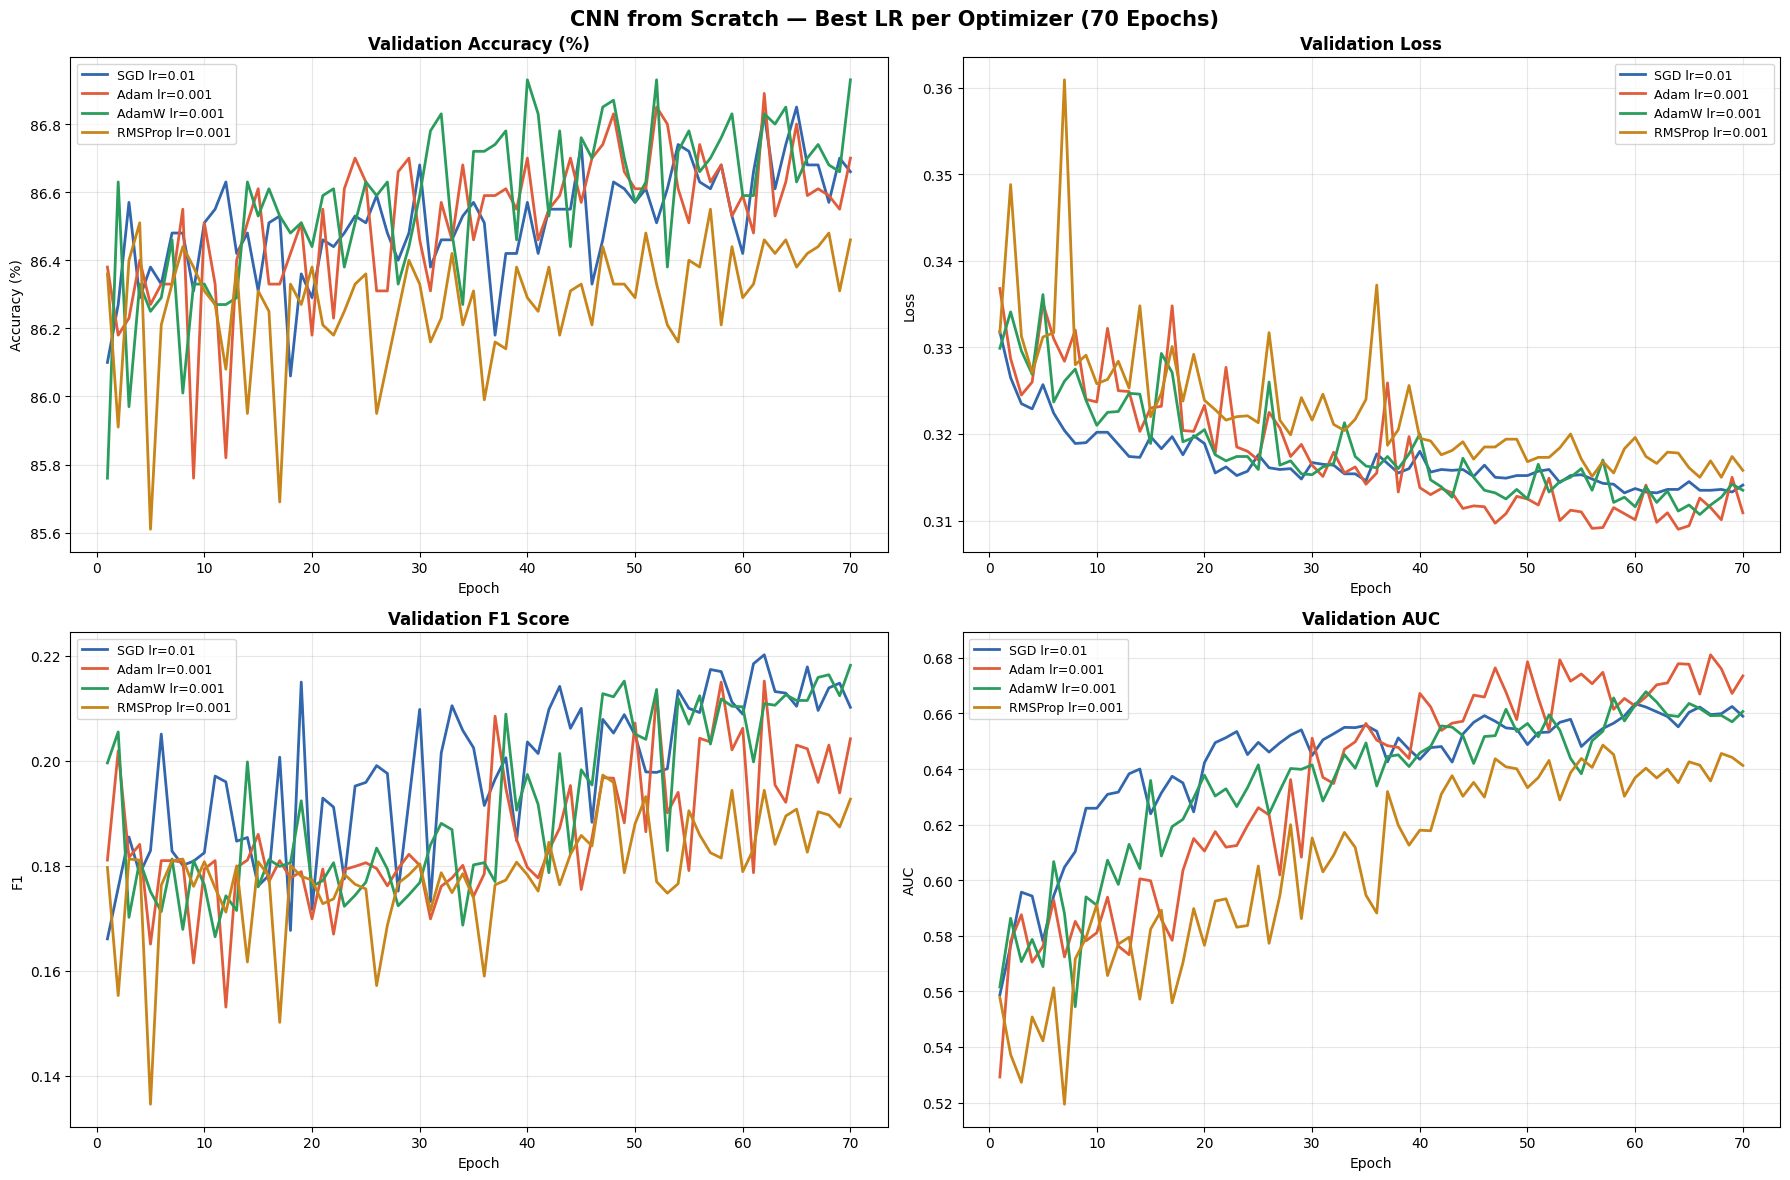

 Graph 1 saved → comparison_best_lr.png


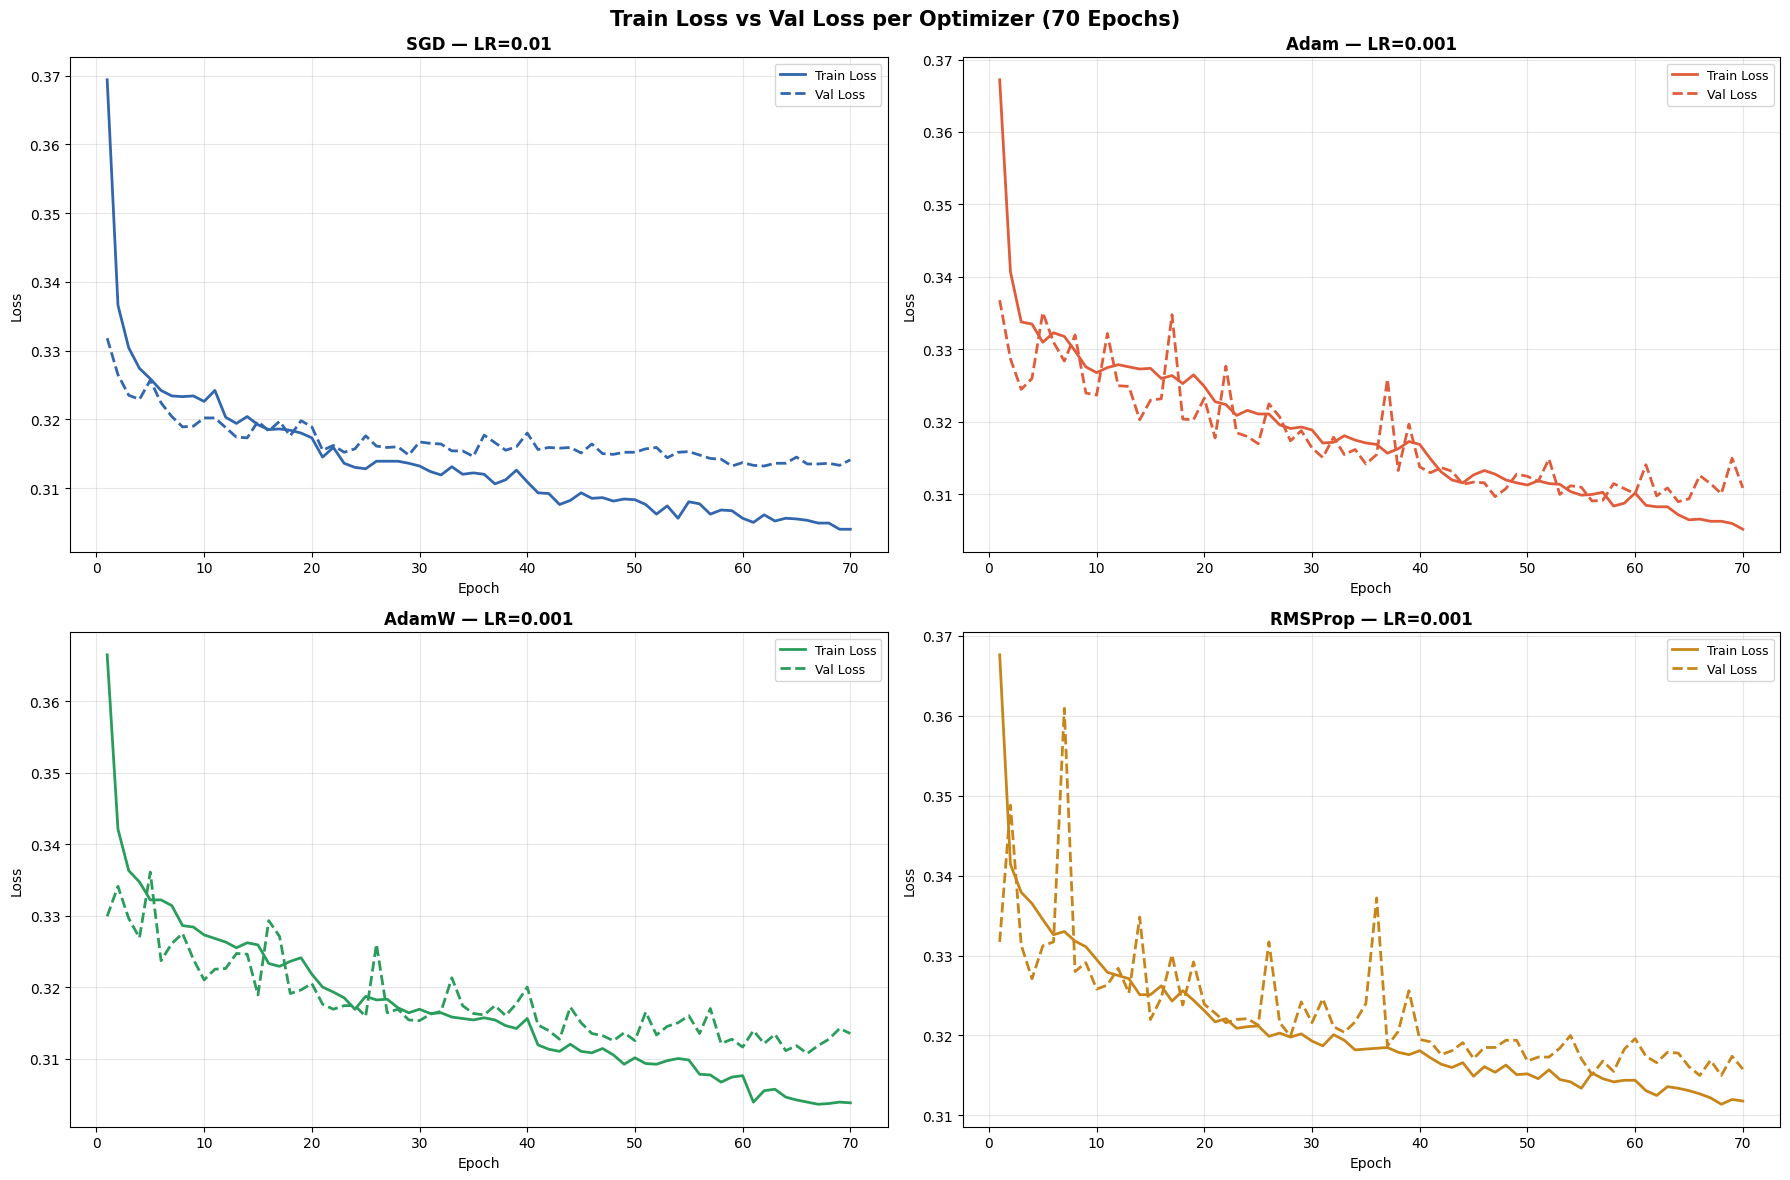

 Graph 2 saved → train_val_loss.png


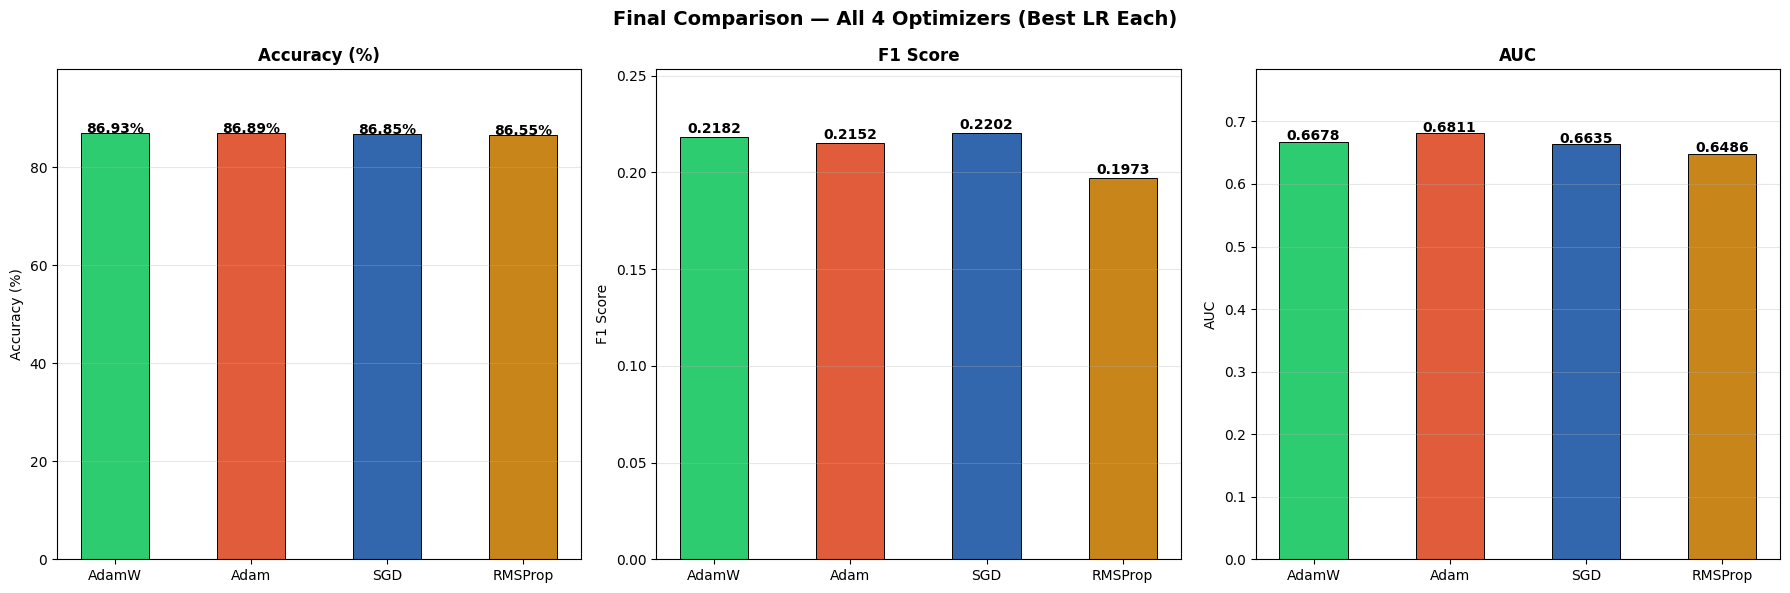

 Graph 3 saved → final_bar_comparison.png

 All 3 graphs saved in ScratchCnnModels/
   Best Optimizer : AdamW
   Best Accuracy  : 86.93%
   Best F1        : 0.2182
   Best AUC       : 0.6678


In [16]:
# ══════════════════════════════════════════════════════════════
#  COMPLETE GRAPH CELL — Run this directly after master fix cell
#  No need to run Cell 22 first
# ══════════════════════════════════════════════════════════════

# ── Build results_df from ALL_RESULTS ────────────────────────
results_df = pd.DataFrame([{
    'Optimizer'   : r['optimizer'],
    'Best LR'     : r['best_lr'],
    'Accuracy (%)': r['best_acc'],
    'F1 Score'    : r['best_f1'],
    'AUC'         : r['best_auc'],
    'Weights'     : r['best_weights'],
} for r in ALL_RESULTS])
results_df = results_df.sort_values(
    'Accuracy (%)', ascending=False).reset_index(drop=True)

# ── Get BEST_OPT ──────────────────────────────────────────────
BEST_OPT = results_df.iloc[0]['Optimizer']
print(f' Best Optimizer : {BEST_OPT}')
print(f' Results loaded : {len(ALL_RESULTS)}/4')

OPT_COLORS = {
    'SGD'    : '#3266ad',
    'Adam'   : '#e05c3a',
    'AdamW'  : '#2a9d5c',
    'RMSProp': '#c8851a',
}
epochs_range = range(1, EPOCHS + 1)

# ══════════════════════════════════════════════════════════════
# GRAPH 1 — Val Acc / Val Loss / F1 / AUC — all 4 optimizers
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('CNN from Scratch — Best LR per Optimizer (70 Epochs)',
             fontsize=15, fontweight='bold')

for opt_name, color in OPT_COLORS.items():
    if opt_name not in ALL_HISTORIES:
        continue
    result  = next(r for r in ALL_RESULTS if r['optimizer'] == opt_name)
    best_lr = result['best_lr']
    h       = ALL_HISTORIES[opt_name]

    axes[0,0].plot(epochs_range, h['val_acc'],
                   label=f'{opt_name} lr={best_lr}',
                   color=color, linewidth=2)
    axes[0,1].plot(epochs_range, h['val_loss'],
                   label=f'{opt_name} lr={best_lr}',
                   color=color, linewidth=2)
    axes[1,0].plot(epochs_range, h['val_f1'],
                   label=f'{opt_name} lr={best_lr}',
                   color=color, linewidth=2)
    axes[1,1].plot(epochs_range, h['val_auc'],
                   label=f'{opt_name} lr={best_lr}',
                   color=color, linewidth=2)

titles  = ['Validation Accuracy (%)', 'Validation Loss',
           'Validation F1 Score',     'Validation AUC']
ylabels = ['Accuracy (%)', 'Loss', 'F1', 'AUC']
for ax, t, y in zip(axes.flat, titles, ylabels):
    ax.set_title(t, fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(y)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'comparison_best_lr.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(' Graph 1 saved → comparison_best_lr.png')

# ══════════════════════════════════════════════════════════════
# GRAPH 2 — Train Loss vs Val Loss per optimizer
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Train Loss vs Val Loss per Optimizer (70 Epochs)',
             fontsize=15, fontweight='bold')

for idx, (opt_name, color) in enumerate(OPT_COLORS.items()):
    if opt_name not in ALL_HISTORIES:
        continue
    ax  = axes.flat[idx]
    h   = ALL_HISTORIES[opt_name]
    lr  = next(r for r in ALL_RESULTS if r['optimizer'] == opt_name)['best_lr']
    ax.plot(epochs_range, h['train_loss'], color=color,
            linewidth=2, label='Train Loss')
    ax.plot(epochs_range, h['val_loss'],   color=color,
            linewidth=2, linestyle='dashed', label='Val Loss')
    ax.set_title(f'{opt_name} — LR={lr}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'train_val_loss.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(' Graph 2 saved → train_val_loss.png')

# ══════════════════════════════════════════════════════════════
# GRAPH 3 — Final Bar Chart Acc / F1 / AUC
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Final Comparison — All 4 Optimizers (Best LR Each)',
             fontsize=14, fontweight='bold')

names = results_df['Optimizer'].tolist()
clrs  = ['#2ecc71' if n == BEST_OPT else OPT_COLORS[n] for n in names]

for ax, metric, ylabel in zip(
    axes,
    ['Accuracy (%)', 'F1 Score', 'AUC'],
    ['Accuracy (%)', 'F1 Score', 'AUC']
):
    vals = results_df[metric].tolist()
    bars = ax.bar(names, vals, color=clrs,
                  edgecolor='black', linewidth=0.7, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.2f}%' if metric == 'Accuracy (%)' else f'{val:.4f}',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(ylabel, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    # Mark best
    best_idx = names.index(BEST_OPT)
    ax.text(best_idx, vals[best_idx] * 0.5,
            ' ', ha='center', fontsize=16)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'final_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(' Graph 3 saved → final_bar_comparison.png')

print('\n All 3 graphs saved in ScratchCnnModels/')
print(f'   Best Optimizer : {BEST_OPT}')
print(f'   Best Accuracy  : {results_df.iloc[0]["Accuracy (%)"]:.2f}%')
print(f'   Best F1        : {results_df.iloc[0]["F1 Score"]:.4f}')
print(f'   Best AUC       : {results_df.iloc[0]["AUC"]:.4f}')

In [17]:
# ══════════════════════════════════════════════════════════════
#  FINAL TEST SET RESULTS — Best Model
#  Restart-safe — reads everything from disk
# ══════════════════════════════════════════════════════════════

# ── Load best model info from disk ───────────────────────────
with open(SAVE_DIR / 'best_model_info.json') as f:
    info = json.load(f)

BEST_OPT = info['best_optimizer']

# ── Load best model weights ───────────────────────────────────
best_model = ScratchCNN().to(DEVICE)
best_model.load_state_dict(
    torch.load(SAVE_DIR / 'best_scratch_cnn.pth', map_location=DEVICE))
best_model.eval()

# ── Evaluate on test set ──────────────────────────────────────
test_m = evaluate(best_model, test_loader)

print('=' * 55)
print('  FINAL TEST SET RESULTS — Best Model')
print('=' * 55)
print(f'  Optimizer      : {info["best_optimizer"]}')
print(f'  Best LR        : {info["best_lr"]}')
print(f'  Epochs         : {info["epochs"]}')
print(f'  Input          : Frontal + Lateral (6-channel)')
print(f'  Image Size     : {info["img_size"]}×{info["img_size"]}')
print('─' * 55)
print(f'  Test Accuracy  : {test_m["accuracy"]:.2f}%')
print(f'  Test F1 Score  : {test_m["f1"]:.4f}')
print(f'  Test AUC       : {test_m["auc"]:.4f}')
print(f'  Test Loss      : {test_m["loss"]:.4f}')
print('=' * 55)

  FINAL TEST SET RESULTS — Best Model
  Optimizer      : AdamW
  Best LR        : 0.001
  Epochs         : 70
  Input          : Frontal + Lateral (6-channel)
  Image Size     : 128×128
───────────────────────────────────────────────────────
  Test Accuracy  : 86.89%
  Test F1 Score  : 0.2055
  Test AUC       : 0.6596
  Test Loss      : 0.3140


## Cell 14 — Per-Class Accuracy (14 Diseases)

Per-Class Accuracy — AdamW Best Model (Test Set)
──────────────────────────────────────────────────────────
   Enlarged Cardiomediastinum         : 100.00%  ██████████████████████████████████████████████████
   Cardiomegaly                       :  93.41%  ██████████████████████████████████████████████
   Lung Opacity                       :  80.84%  ████████████████████████████████████████
   Lung Lesion                        :  91.62%  █████████████████████████████████████████████
   Edema                              :  92.81%  ██████████████████████████████████████████████
   Consolidation                      :  52.10%  ██████████████████████████
   Pneumonia                          :  94.01%  ███████████████████████████████████████████████
   Atelectasis                        :  87.43%  ███████████████████████████████████████████
   Pneumothorax                       :  56.29%  ████████████████████████████
   Pleural Effusion                   :  73.95%  ██████████████████████

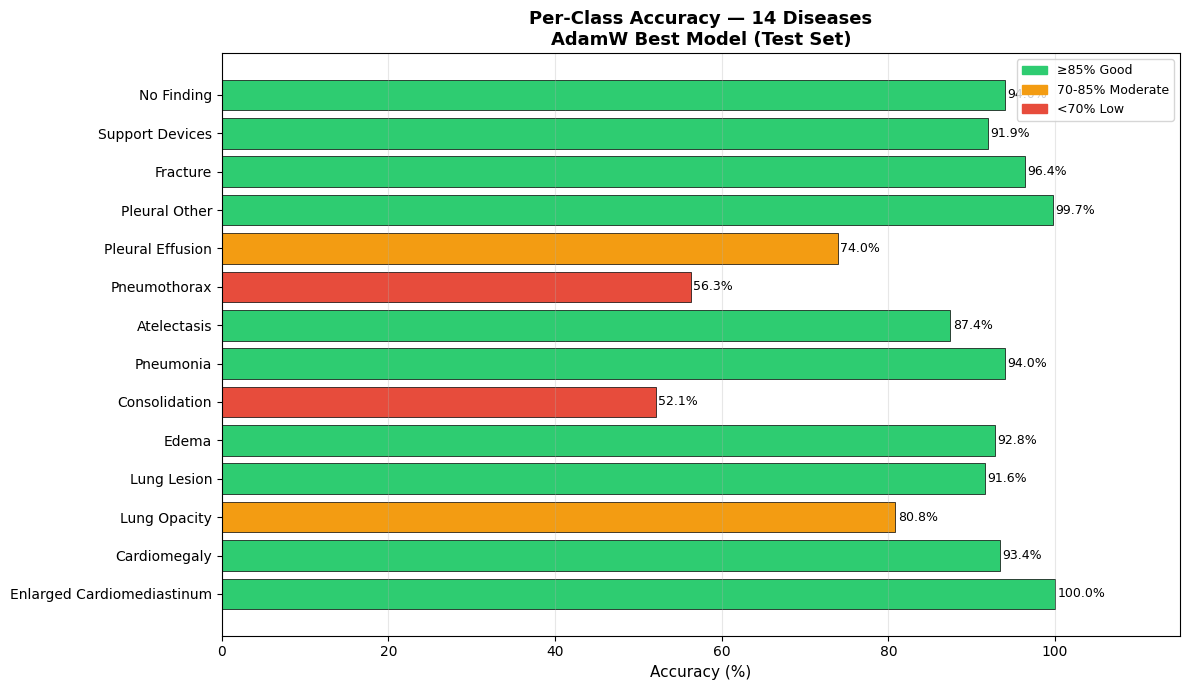

 Saved → ScratchCnnModels/per_class_accuracy.png


In [18]:
best_model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        preds = best_model(images.to(DEVICE)).cpu()
        all_preds.append(preds)
        all_targets.append(labels)

all_preds   = (torch.cat(all_preds).numpy() > 0.5).astype(float)
all_targets = torch.cat(all_targets).numpy()
per_cls     = (all_preds == all_targets).mean(axis=0) * 100

print(f'Per-Class Accuracy — {BEST_OPT} Best Model (Test Set)')
print('─' * 58)
for cls, acc in zip(FINDINGS_COLS, per_cls):
    icon = '' if acc>=85 else '' if acc>=70 else ''
    bar  = '█' * int(acc/2)
    print(f'  {icon} {cls:<35}: {acc:6.2f}%  {bar}')
print(f'\n  Overall Avg : {per_cls.mean():.2f}%')

bar_colors = ['#2ecc71' if a>=85 else '#f39c12'
              if a>=70 else '#e74c3c' for a in per_cls]
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(FINDINGS_COLS, per_cls, color=bar_colors,
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, per_cls):
    ax.text(bar.get_width()+0.3,
            bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title(
    f'Per-Class Accuracy — 14 Diseases\n{BEST_OPT} Best Model (Test Set)',
    fontweight='bold', fontsize=13)
ax.set_xlim(0, 115)
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='≥85% Good'),
    mpatches.Patch(color='#f39c12', label='70-85% Moderate'),
    mpatches.Patch(color='#e74c3c', label='<70% Low'),
], fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_DIR/'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(f' Saved → {SAVE_DIR}/per_class_accuracy.png')

## Cell 15 — Load Saved Models in VS Code
> Run this next time in VS Code — **no retraining needed!**

In [19]:
# ══════════════════════════════════════════════════════════════
#  AFTER RESTART — Run Cell 1→6 (setup), then THIS CELL
#  Loads ALL 4 trained models from disk. No retraining needed!
# ══════════════════════════════════════════════════════════════

print('Loading all 4 trained models from disk...\n')

LOADED_MODELS = {}

for opt_name in ['SGD', 'Adam', 'AdamW', 'RMSProp']:
    model_path = SAVE_DIR / f'{opt_name}_best.pth'
    if model_path.exists():
        m = ScratchCNN().to(DEVICE)
        m.load_state_dict(torch.load(model_path, map_location=DEVICE))
        m.eval()
        LOADED_MODELS[opt_name] = m
        print(f'   {opt_name:<10} loaded ← {model_path}')
    else:
        print(f'   {opt_name:<10} not found — train first')

# Load best overall model
best_path = SAVE_DIR / 'best_scratch_cnn.pth'
if best_path.exists():
    best_model_vs = ScratchCNN().to(DEVICE)
    best_model_vs.load_state_dict(torch.load(best_path, map_location=DEVICE))
    best_model_vs.eval()
    LOADED_MODELS['best'] = best_model_vs
    print(f'\n   best_scratch_cnn loaded ← {best_path}')

# Load info JSON
info_path = SAVE_DIR / 'best_model_info.json'
if info_path.exists():
    with open(info_path) as f:
        info = json.load(f)
    print('\nBest Model Info:')
    for k, v in info.items():
        print(f'  {k:<18}: {v}')

# Sanity forward-pass check
print('\nForward pass check (best model):')
with torch.no_grad():
    dummy = torch.randn(2, 6, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = LOADED_MODELS['best'](dummy)
print(f'  Input  : {list(dummy.shape)}')
print(f'  Output : {list(out.shape)}  ← should be [2, 14]')
# print(f'  Range  : {out.min():.3f} – {out.max():.3f}  ← should be 0–1')
print(f'\n All {len(LOADED_MODELS)} models loaded and ready!')

Loading all 4 trained models from disk...

   SGD        loaded ← ScratchCnnModels\SGD_best.pth
   Adam       loaded ← ScratchCnnModels\Adam_best.pth
   AdamW      loaded ← ScratchCnnModels\AdamW_best.pth
   RMSProp    loaded ← ScratchCnnModels\RMSProp_best.pth

   best_scratch_cnn loaded ← ScratchCnnModels\best_scratch_cnn.pth

Best Model Info:
  best_optimizer    : AdamW
  best_lr           : 0.001
  best_accuracy     : 86.93
  best_f1           : 0.2182
  best_auc          : 0.6678
  epochs            : 70
  img_size          : 128
  input_channels    : 6
  weights           : ScratchCnnModels\best_scratch_cnn.pth

Forward pass check (best model):
  Input  : [2, 6, 128, 128]
  Output : [2, 14]  ← should be [2, 14]

 All 5 models loaded and ready!
